In [8]:
from Metode_Iteratif.jacobi import Jacobi
from Metode_Iteratif.gauss_seidel import GaussSeidel
import numpy as np
import matplotlib.pyplot as plt

METODE JACOBI

=== ITERASI JACOBI ===
Iterasi  1: 0.600000  2.272727  -1.100000  1.875000 | error = 2.272727e+00
Iterasi  2: 1.047273  1.715909  -0.805227  0.885227 | error = 9.897727e-01
Iterasi  3: 0.932636  2.053306  -1.049341  1.130881 | error = 3.373967e-01
Iterasi  4: 1.015199  1.953696  -0.968109  0.973843 | error = 1.570380e-01
Iterasi  5: 0.988991  2.011415  -1.010286  1.021351 | error = 5.771896e-02
Iterasi  6: 1.003199  1.992241  -0.994522  0.994434 | error = 2.691677e-02
Iterasi  7: 0.998128  2.002307  -1.001972  1.003594 | error = 1.006562e-02
Iterasi  8: 1.000625  1.998670  -0.999036  0.998888 | error = 4.705920e-03
Iterasi  9: 0.999674  2.000448  -1.000369  1.000619 | error = 1.777370e-03
Iterasi 10: 1.000119  1.999768  -0.999828  0.999786 | error = 8.332117e-04
Iterasi 11: 0.999942  2.000085  -1.000068  1.000109 | error = 3.225236e-04
Iterasi 12: 1.000022  1.999959  -0.999969  0.999960 | error = 1.488334e-04
Iterasi 13: 0.999990  2.000016  -1.000013  1.000019 | error = 

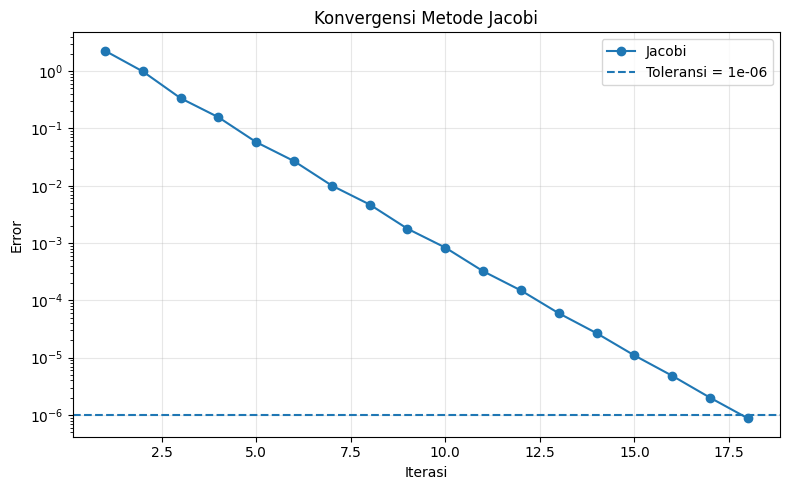

In [9]:
A = [
    [10, -1, 2, 0],
    [-1, 11, -1, 3],
    [2, -1, 10, -1],
    [0, 3, -1, 8]
]

b = [6, 25, -11, 15]
x0 = [0, 0, 0, 0]
tol = 1e-6
max_iter = 50

print("=" * 60)
print("METODE JACOBI")
print("=" * 60)

jacobi = Jacobi(A, b, x0=x0, tol=tol, max_iter=max_iter)
jacobi.solve()
jacobi.tampilkan_iterasi()
jacobi.hasil()

print("\nResidu Jacobi:")
print(jacobi.residu())

# Plot Jacobi
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(jacobi.errors) + 1), jacobi.errors, marker='o', label='Jacobi')
plt.axhline(y=tol, linestyle='--', label=f'Toleransi = {tol}')
plt.yscale('log')
plt.xlabel('Iterasi')
plt.ylabel('Error')
plt.title('Konvergensi Metode Jacobi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
print("\n" + "=" * 60)
print("METODE GAUSS-SEIDEL")
print("=" * 60)

gauss = GaussSeidel(A, b, x0=x0, tol=tol, max_iter=max_iter)
gauss.solve()
gauss.tampilkan_iterasi()
gauss.hasil()

print("\nResidu Gauss-Seidel:")
print(gauss.residu())


METODE GAUSS-SEIDEL

=== ITERASI GAUSS-SEIDEL ===
Iterasi  1: 0.600000  2.327273  -0.987273  0.878864 | error = 2.327273e+00
Iterasi  2: 1.030182  2.036938  -1.014456  0.984341 | error = 4.301818e-01
Iterasi  3: 1.006585  2.003555  -1.002527  0.998351 | error = 3.338300e-02
Iterasi  4: 1.000861  2.000298  -1.000307  0.999850 | error = 5.724063e-03
Iterasi  5: 1.000091  2.000021  -1.000031  0.999988 | error = 7.696983e-04
Iterasi  6: 1.000008  2.000001  -1.000003  0.999999 | error = 8.291662e-05
Iterasi  7: 1.000001  2.000000  -1.000000  1.000000 | error = 7.697313e-06
Iterasi  8: 1.000000  2.000000  -1.000000  1.000000 | error = 6.220629e-07

HASIL METODE GAUSS-SEIDEL
x1 = 1.00000004
x2 = 1.99999999
x3 = -1.00000001
x4 = 1.00000000
Jumlah iterasi : 8
Error akhir    : 6.22062942e-07
Status         : Konvergen

Residu Gauss-Seidel:
[ 4.22335984e-07 -8.89315714e-08 -3.57543506e-08 -1.77635684e-15]


In [11]:
print("\n" + "=" * 60)
print("PERBANDINGAN LENGKAP JACOBI VS GAUSS-SEIDEL")
print("=" * 60)

solusi_exact = np.linalg.solve(np.array(A, dtype=float), np.array(b, dtype=float))

print("\nSolusi Eksak (NumPy):")
for i, val in enumerate(solusi_exact, start=1):
    print(f"x{i} = {val:.8f}")

print("\nHasil Akhir Jacobi:")
for i, val in enumerate(jacobi.x, start=1):
    print(f"x{i} = {val:.8f}")

print("\nHasil Akhir Gauss-Seidel:")
for i, val in enumerate(gauss.x, start=1):
    print(f"x{i} = {val:.8f}")

print("\nJumlah Iterasi:")
print(f"Jacobi        : {jacobi.iterations}")
print(f"Gauss-Seidel  : {gauss.iterations}")

print("\nError Akhir:")
print(f"Jacobi        : {jacobi.errors[-1]:.8e}")
print(f"Gauss-Seidel  : {gauss.errors[-1]:.8e}")

print("\nResidu:")
print(f"Jacobi        : {jacobi.residu()}")
print(f"Gauss-Seidel  : {gauss.residu()}")

if jacobi.iterations > gauss.iterations:
    print("\nKesimpulan: Gauss-Seidel lebih cepat konvergen dibanding Jacobi.")
elif jacobi.iterations < gauss.iterations:
    print("\nKesimpulan: Jacobi lebih cepat konvergen dibanding Gauss-Seidel.")
else:
    print("\nKesimpulan: Keduanya memiliki jumlah iterasi yang sama.")



PERBANDINGAN LENGKAP JACOBI VS GAUSS-SEIDEL

Solusi Eksak (NumPy):
x1 = 1.00000000
x2 = 2.00000000
x3 = -1.00000000
x4 = 1.00000000

Hasil Akhir Jacobi:
x1 = 1.00000014
x2 = 1.99999976
x3 = -0.99999982
x4 = 0.99999975

Hasil Akhir Gauss-Seidel:
x1 = 1.00000004
x2 = 1.99999999
x3 = -1.00000001
x4 = 1.00000000

Jumlah Iterasi:
Jacobi        : 18
Gauss-Seidel  : 8

Error Akhir:
Jacobi        : 8.73086081e-07
Gauss-Seidel  : 6.22062942e-07

Residu:
Jacobi        : [ 1.97994683e-06 -3.69241333e-06  2.58866112e-06 -2.92648805e-06]
Gauss-Seidel  : [ 4.22335984e-07 -8.89315714e-08 -3.57543506e-08 -1.77635684e-15]

Kesimpulan: Gauss-Seidel lebih cepat konvergen dibanding Jacobi.


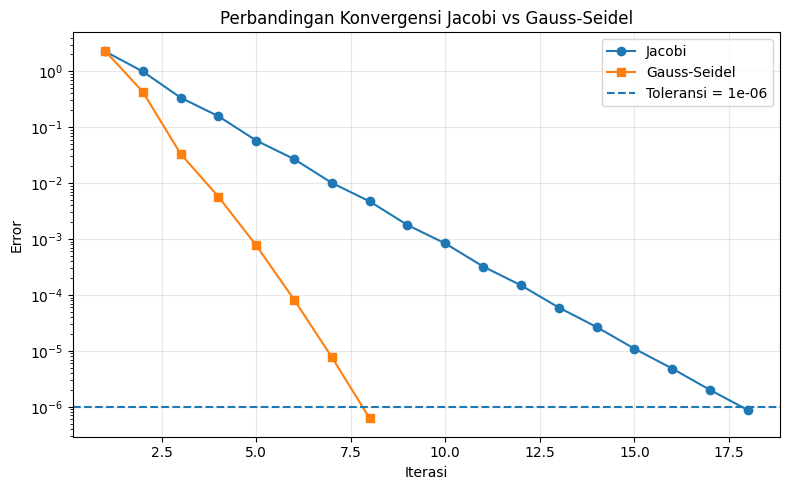

In [12]:
# Plot perbandingan
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(jacobi.errors) + 1), jacobi.errors, marker='o', label='Jacobi')
plt.plot(range(1, len(gauss.errors) + 1), gauss.errors, marker='s', label='Gauss-Seidel')
plt.axhline(y=tol, linestyle='--', label=f'Toleransi = {tol}')
plt.yscale('log')
plt.xlabel('Iterasi')
plt.ylabel('Error')
plt.title('Perbandingan Konvergensi Jacobi vs Gauss-Seidel')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()